In [ ]:
!gdown 1RcH4FpfN7JuXWxoAWcfpV0TLkq4W8zKw

Downloading...
From (original): https://drive.google.com/uc?id=1RcH4FpfN7JuXWxoAWcfpV0TLkq4W8zKw
From (redirected): https://drive.google.com/uc?id=1RcH4FpfN7JuXWxoAWcfpV0TLkq4W8zKw&confirm=t&uuid=f79749e6-374b-4406-9aa3-ae2ba95400b9
To: /content/data.zip
100% 363M/363M [00:09<00:00, 37.4MB/s]


In [ ]:
!unzip -q /content/data.zip

In [ ]:
!pip install opencv-python

In [ ]:
import os
import json
import hashlib
from pathlib import Path
import cv2
import random

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

SEED = 42
np.random.seed(SEED)

In [ ]:
# =========================
# CẤU HÌNH MÔI TRƯỜNG LOCAL
# =========================

PROJECT_ROOT = Path("D:/intel_image_project")   # sửa lại theo máy của bạn

VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
VAL_SIZE = 0.2
IMAGE_SIZE = (150, 150)

# Mean/std bạn đã tính từ EDA
DATASET_MEAN = [0.43018116, 0.45747542, 0.45382798]
DATASET_STD  = [0.26941103, 0.26793626, 0.29834034]

# Mean/std ImageNet để dùng sau này nếu transfer learning
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

NORMALIZE_MODE = "dataset"
SEED = 42


def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)


DATA_ROOT = PROJECT_ROOT / "data" / "raw"
ARTIFACT_ROOT = PROJECT_ROOT

TRAIN_DIR = DATA_ROOT / "seg_train"
TEST_DIR = DATA_ROOT / "seg_test"
PRED_DIR = DATA_ROOT / "seg_pred"

METADATA_DIR = ARTIFACT_ROOT / "data" / "metadata"
SPLITS_DIR = ARTIFACT_ROOT / "data" / "splits"
FIG_DIR = ARTIFACT_ROOT / "outputs" / "figures" / "preprocessing"

for d in [METADATA_DIR, SPLITS_DIR, FIG_DIR]:
    ensure_dir(d)

print("PROJECT_ROOT    :", PROJECT_ROOT)
print("DATA_ROOT       :", DATA_ROOT)
print("ARTIFACT_ROOT   :", ARTIFACT_ROOT)
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("TEST_DIR exists :", TEST_DIR.exists())
print("PRED_DIR exists :", PRED_DIR.exists())

In [ ]:
TRAIN_DIR = Path("/content/seg_train/seg_train")
TEST_DIR = Path("/content/seg_test/seg_test")
PRED_DIR = Path("/content/seg_pred/seg_pred")

METADATA_DIR = Path("/content/metadata")
SPLITS_DIR = Path("/content/splits")
FIG_DIR = Path("/content/figures/preprocessing")

for d in [METADATA_DIR, SPLITS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("TEST_DIR exists :", TEST_DIR.exists())
print("PRED_DIR exists :", PRED_DIR.exists())

TRAIN_DIR exists: True
TEST_DIR exists : True
PRED_DIR exists : True


In [ ]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
DATA_ROOT = Path("/content/")

def collect_image_paths(split_dir, split_name, has_class_subfolders=True, valid_exts=VALID_EXTS):
    records = []

    if not split_dir.exists():
        print(f"[WARNING] Không tìm thấy thư mục: {split_dir}")
        return pd.DataFrame(columns=["split", "label", "file_name", "relative_path"])

    if has_class_subfolders:
        class_dirs = [d for d in split_dir.iterdir() if d.is_dir()]

        for class_dir in sorted(class_dirs):
            label = class_dir.name

            for img_path in sorted(class_dir.rglob("*")):
                if img_path.is_file() and img_path.suffix.lower() in valid_exts:
                    # Use DATA_ROOT defined in this scope
                    relative_path = img_path.relative_to(DATA_ROOT).as_posix()
                    records.append({
                        "split": split_name,
                        "label": label,
                        "file_name": img_path.name,
                        "relative_path": relative_path
                    })
    else:
        for img_path in sorted(split_dir.glob("*")):
            if img_path.is_file() and img_path.suffix.lower() in valid_exts:
                # Use DATA_ROOT defined in this scope
                relative_path = img_path.relative_to(DATA_ROOT).as_posix()
                records.append({
                    "split": split_name,
                    "label": None,
                    "file_name": img_path.name,
                    "relative_path": relative_path
                })

    return pd.DataFrame(records)


df_train = collect_image_paths(TRAIN_DIR, "train", has_class_subfolders=True)
df_test  = collect_image_paths(TEST_DIR, "test", has_class_subfolders=True)
df_pred  = collect_image_paths(PRED_DIR, "pred", has_class_subfolders=False)

df_all = pd.concat([df_train, df_test, df_pred], ignore_index=True)

print("Tổng số ảnh:", len(df_all))
print(df_all.head())

[WARNING] Không tìm thấy thư mục: D:/intel_image_project/data/raw/seg_train
[WARNING] Không tìm thấy thư mục: D:/intel_image_project/data/raw/seg_test
[WARNING] Không tìm thấy thư mục: D:/intel_image_project/data/raw/seg_pred
Tổng số ảnh: 0
Empty DataFrame
Columns: [split, label, file_name, relative_path]
Index: []


In [ ]:
def get_image_info(relative_path):
    img_path = DATA_ROOT / relative_path

    try:
        with Image.open(img_path) as img:
            width, height = img.size
            mode = img.mode
        return width, height, mode, None
    except (UnidentifiedImageError, OSError) as e:
        return None, None, None, str(e)


widths = []
heights = []
modes = []
errors = []

for rel_path in tqdm(df_all["relative_path"], desc="Đọc metadata ảnh"):
    w, h, m, err = get_image_info(rel_path)
    widths.append(w)
    heights.append(h)
    modes.append(m)
    errors.append(err)

df_all["width"] = widths
df_all["height"] = heights
df_all["mode"] = modes
df_all["error"] = errors

print("Số ảnh lỗi:", df_all["error"].notna().sum())
df_all.head()

Đọc metadata ảnh:   0%|          | 0/24335 [00:00<?, ?it/s]

Số ảnh lỗi: 0


,split,label,file_name,relative_path,width,height,mode,error
0,train,buildings,0.jpg,seg_train/seg_train/buildings/0.jpg,150,150,RGB,None
1,train,buildings,10006.jpg,seg_train/seg_train/buildings/10006.jpg,150,150,RGB,None
2,train,buildings,1001.jpg,seg_train/seg_train/buildings/1001.jpg,150,150,RGB,None
3,train,buildings,10014.jpg,seg_train/seg_train/buildings/10014.jpg,150,150,RGB,None
4,train,buildings,10018.jpg,seg_train/seg_train/buildings/10018.jpg,150,150,RGB,None


In [ ]:
def get_file_md5(relative_path, chunk_size=8192):
    file_path = DATA_ROOT / relative_path
    md5 = hashlib.md5()

    try:
        with open(file_path, "rb") as f:
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                md5.update(chunk)
        return md5.hexdigest()
    except Exception:
        return None


df_clean = df_all[df_all["error"].isna()].copy().reset_index(drop=True)

df_clean["file_hash"] = [
    get_file_md5(rel_path) for rel_path in tqdm(df_clean["relative_path"], desc="Tính MD5")
]

print("Số ảnh hợp lệ:", len(df_clean))
df_clean.head()

Tính MD5:   0%|          | 0/24335 [00:00<?, ?it/s]

Số ảnh hợp lệ: 24335


,split,label,file_name,relative_path,width,height,mode,error,file_hash
0,train,buildings,0.jpg,seg_train/seg_train/buildings/0.jpg,150,150,RGB,None,96bffbc78c172412ea735e9c654794d2
1,train,buildings,10006.jpg,seg_train/seg_train/buildings/10006.jpg,150,150,RGB,None,e5c6d11cd56819ccffaedcec416b665a
2,train,buildings,1001.jpg,seg_train/seg_train/buildings/1001.jpg,150,150,RGB,None,0b67dcb47fefd82ec7caa639daee4b73
3,train,buildings,10014.jpg,seg_train/seg_train/buildings/10014.jpg,150,150,RGB,None,61c4f6b97194e0566334bd7cce858854
4,train,buildings,10018.jpg,seg_train/seg_train/buildings/10018.jpg,150,150,RGB,None,fc2d7bb4d6d62f83524a662ce2573941


In [ ]:
# Duplicate trong cùng split
duplicates_within_split = df_clean[
    df_clean.duplicated(subset=["split", "file_hash"], keep=False)
].copy().sort_values(["split", "file_hash", "relative_path"])

# Duplicate xuyên split
hash_split_counts = df_clean.groupby("file_hash")["split"].nunique()
cross_split_hashes = set(hash_split_counts[hash_split_counts > 1].index)

duplicates_cross_split = df_clean[
    df_clean["file_hash"].isin(cross_split_hashes)
].copy().sort_values(["file_hash", "split", "relative_path"])

print("Số dòng duplicate trong cùng split:", len(duplicates_within_split))
print("Số dòng duplicate xuyên split     :", len(duplicates_cross_split))


train_df = df_clean[df_clean["split"] == "train"].copy()
test_df  = df_clean[df_clean["split"] == "test"].copy()
pred_df  = df_clean[df_clean["split"] == "pred"].copy()

original_train_count = len(train_df)

# Loại train image nếu hash đã xuất hiện ở test để tránh leakage
test_hashes = set(test_df["file_hash"])
train_df["leaks_to_test"] = train_df["file_hash"].isin(test_hashes)

num_leak_train = train_df["leaks_to_test"].sum()
print("Số ảnh train bị trùng với test:", num_leak_train)

train_df = train_df[~train_df["leaks_to_test"]].copy()

# Loại duplicate nội bộ trong train
before_dedup_train = len(train_df)
train_df = train_df.drop_duplicates(subset=["file_hash"], keep="first").reset_index(drop=True)
after_dedup_train = len(train_df)

print("Train trước làm sạch:", original_train_count)
print("Train sau bỏ leakage :", before_dedup_train)
print("Train sau dedup      :", after_dedup_train)

Số dòng duplicate trong cùng split: 40
Số dòng duplicate xuyên split     : 54
Số ảnh train bị trùng với test: 3
Train trước làm sạch: 14034
Train sau bỏ leakage : 14031
Train sau dedup      : 14016


In [ ]:
# =========================
# 1. LƯU LẠI ẢNH BỊ XÓA
# =========================

train_df_full = df_clean[df_clean["split"] == "train"].copy()
test_df = df_clean[df_clean["split"] == "test"].copy()

# Các hash xuất hiện trong test
test_hashes = set(test_df["file_hash"])

# Ảnh train bị trùng với test -> leakage
removed_leakage = train_df_full[train_df_full["file_hash"].isin(test_hashes)].copy()
removed_leakage["remove_reason"] = "leak_to_test"

# Train sau khi bỏ leakage
train_after_leak = train_df_full[~train_df_full["file_hash"].isin(test_hashes)].copy()

# Ảnh bị xóa do duplicate nội bộ trong train
dup_mask = train_after_leak.duplicated(subset=["file_hash"], keep="first")
removed_internal_dup = train_after_leak[dup_mask].copy()
removed_internal_dup["remove_reason"] = "duplicate_in_train"

# Gộp tất cả ảnh đã bị xóa
removed_images = pd.concat([removed_leakage, removed_internal_dup], ignore_index=True)

print("Tổng số ảnh đã bị xóa:", len(removed_images))
print(removed_images[["split", "label", "relative_path", "remove_reason"]].head())

Tổng số ảnh đã bị xóa: 18
   split      label                           relative_path  \
0  train  buildings  seg_train/seg_train/buildings/4634.jpg   
1  train   mountain  seg_train/seg_train/mountain/14341.jpg   
2  train     street    seg_train/seg_train/street/10408.jpg   
3  train     forest    seg_train/seg_train/forest/18807.jpg   
4  train     forest     seg_train/seg_train/forest/8689.jpg   

        remove_reason  
0        leak_to_test  
1        leak_to_test  
2        leak_to_test  
3  duplicate_in_train  
4  duplicate_in_train  


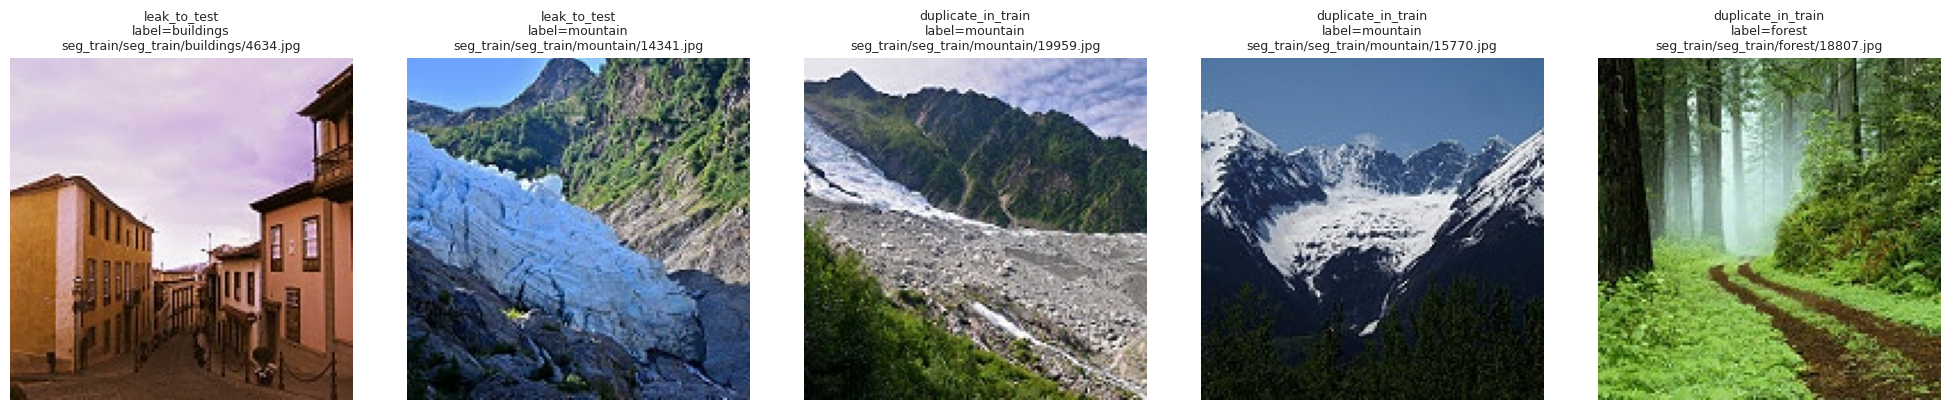

In [ ]:
# =========================
# 2. HIỂN THỊ 5 ẢNH RANDOM ĐÃ BỊ XÓA
# =========================

num_samples = min(5, len(removed_images))
sample_df = removed_images.sample(n=num_samples, random_state=None).reset_index(drop=True)

fig, axes = plt.subplots(1, num_samples, figsize=(4 * num_samples, 4))

if num_samples == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img_path = DATA_ROOT / row["relative_path"]

    try:
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(
            f"{row['remove_reason']}\n"
            f"label={row['label']}\n"
            f"{row['relative_path']}",
            fontsize=9
        )
    except Exception as e:
        ax.text(0.5, 0.5, f"Lỗi đọc ảnh\n{row['relative_path']}",
                ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Tạo validation split từ train
train_final_df, val_df = train_test_split(
    train_df,
    test_size=VAL_SIZE,
    stratify=train_df["label"],
    random_state=SEED
)

train_final_df = train_final_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
pred_df = pred_df.reset_index(drop=True)

print("Train cuối:", len(train_final_df))
print("Val       :", len(val_df))
print("Test      :", len(test_df))
print("Pred      :", len(pred_df))

Train cuối: 11212
Val       : 2804
Test      : 3000
Pred      : 7301


In [ ]:
classes = sorted(train_final_df["label"].unique())
class_to_idx = {label: idx for idx, label in enumerate(classes)}

def add_label_idx(df, is_pred=False):
    out = df.copy()
    if is_pred:
        out["label_idx"] = -1
    else:
        out["label_idx"] = out["label"].map(class_to_idx)
    return out

train_final_df = add_label_idx(train_final_df, is_pred=False)
val_df = add_label_idx(val_df, is_pred=False)
test_df = add_label_idx(test_df, is_pred=False)
pred_df = add_label_idx(pred_df, is_pred=True)

# Lưu metadata
df_all.to_csv(METADATA_DIR / "raw_metadata_all.csv", index=False)
df_clean.to_csv(METADATA_DIR / "clean_metadata_all.csv", index=False)
duplicates_within_split.to_csv(METADATA_DIR / "duplicates_within_split.csv", index=False)
duplicates_cross_split.to_csv(METADATA_DIR / "duplicates_cross_split.csv", index=False)

# Lưu split
train_final_df.to_csv(SPLITS_DIR / "train.csv", index=False)
val_df.to_csv(SPLITS_DIR / "val.csv", index=False)
test_df.to_csv(SPLITS_DIR / "test.csv", index=False)
pred_df.to_csv(SPLITS_DIR / "pred.csv", index=False)

# Lưu class mapping
with open(METADATA_DIR / "class_to_idx.json", "w", encoding="utf-8") as f:
    json.dump(class_to_idx, f, ensure_ascii=False, indent=2)

summary = {
    "seed": SEED,
    "val_size": VAL_SIZE,
    "image_size": IMAGE_SIZE,
    "normalize_mode": NORMALIZE_MODE,
    "dataset_mean": DATASET_MEAN,
    "dataset_std": DATASET_STD,
    "num_raw_images": int(len(df_all)),
    "num_clean_images": int(len(df_clean)),
    "num_train_final": int(len(train_final_df)),
    "num_val": int(len(val_df)),
    "num_test": int(len(test_df)),
    "num_pred": int(len(pred_df)),
    "num_duplicate_rows_within_split": int(len(duplicates_within_split)),
    "num_duplicate_rows_cross_split": int(len(duplicates_cross_split)),
    "class_to_idx": class_to_idx
}

with open(METADATA_DIR / "preprocessing_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Đã lưu xong metadata và split files.")

Đã lưu xong metadata và split files.


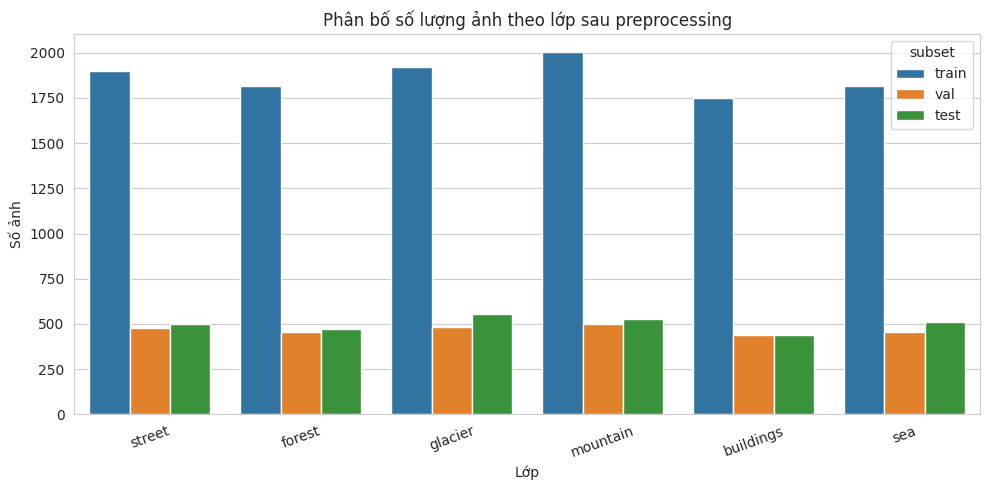

Đã lưu figure tại: /content/figures/preprocessing/class_distribution_after_cleaning.png


In [ ]:
plot_df = pd.concat([
    train_final_df.assign(subset="train"),
    val_df.assign(subset="val"),
    test_df.assign(subset="test")
], ignore_index=True)

plt.figure(figsize=(10, 5))
sns.countplot(data=plot_df, x="label", hue="subset")
plt.title("Phân bố số lượng ảnh theo lớp sau preprocessing")
plt.xlabel("Lớp")
plt.ylabel("Số ảnh")
plt.xticks(rotation=20)
plt.tight_layout()

save_path = FIG_DIR / "class_distribution_after_cleaning.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu figure tại:", save_path)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

if NORMALIZE_MODE == "dataset":
    mean, std = DATASET_MEAN, DATASET_STD
else:
    mean, std = IMAGENET_MEAN, IMAGENET_STD

base_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])


class IntelSceneDataset(Dataset):
    def __init__(self, csv_path, data_root, transform=None):
        self.df = pd.read_csv(csv_path)
        self.data_root = Path(data_root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.data_root / row["relative_path"]

        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label_idx = int(row["label_idx"])
        return img, label_idx, row["relative_path"]


train_dataset = IntelSceneDataset(SPLITS_DIR / "train.csv", DATA_ROOT, transform=base_transform)
val_dataset   = IntelSceneDataset(SPLITS_DIR / "val.csv", DATA_ROOT, transform=base_transform)
test_dataset  = IntelSceneDataset(SPLITS_DIR / "test.csv", DATA_ROOT, transform=base_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

images, labels, paths = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Ví dụ path:", paths[0])

Batch image shape: torch.Size([32, 3, 150, 150])
Batch label shape: torch.Size([32])
Ví dụ path: seg_train/seg_train/glacier/17925.jpg


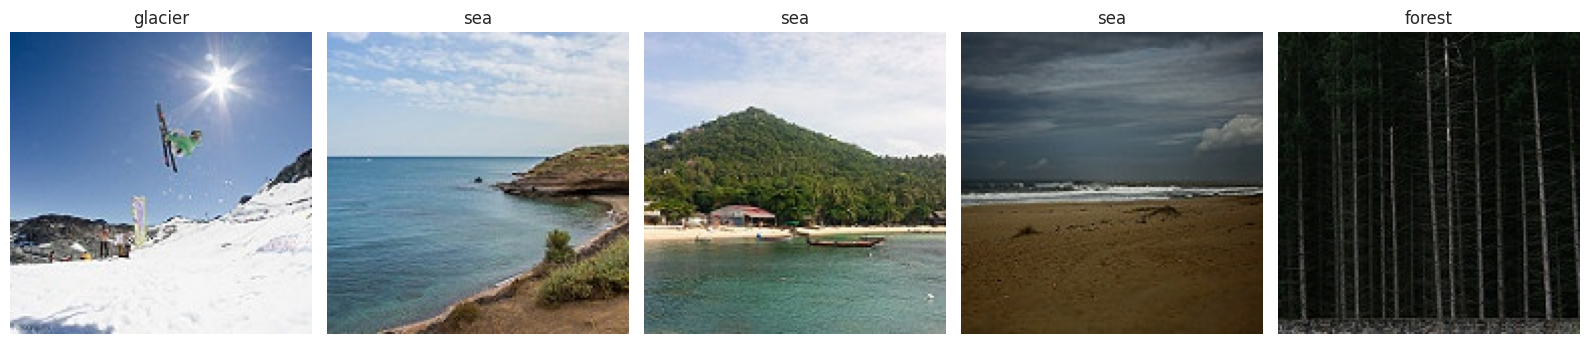

Đã lưu preview tại: /content/figures/preprocessing/preview_transformed_batch.png


In [ ]:
def denormalize(img_tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return img_tensor * std + mean


idx_to_class = {v: k for k, v in class_to_idx.items()}

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for i in range(5):
    img = denormalize(images[i].cpu(), mean, std)
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()

    axes[i].imshow(img)
    axes[i].set_title(idx_to_class[int(labels[i])])
    axes[i].axis("off")

plt.tight_layout()

save_path = FIG_DIR / "preview_transformed_batch.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu preview tại:", save_path)